# 02 - Clean Baseline (Part 1: measure on clean images)

Establishes the baseline every later notebook compares against. Detection
needs an extra step first: a COCO-pretrained YOLOv8 can't be evaluated
against KITTI's own classes (no Pedestrian/Cyclist/Van/Tram in COCO), so its
head is fine-tuned on KITTI's classes here - that fine-tuned checkpoint, not
raw COCO-YOLO, is the detection "baseline" for every notebook downstream.
SegFormer needs no such step: a Cityscapes-pretrained checkpoint already
shares KITTI Semantics' class taxonomy.

In [8]:
import os
import sys

IN_COLAB = "google.colab" in str(get_ipython())
REPO_URL = "https://github.com/Shir-Siman-Tov/Image-Processing-Project.git"
REPO_DIR = "/content/Image-Processing-Project"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.exists(REPO_DIR):
        get_ipython().system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        # Runtime already had this repo cloned from an earlier cell run in this
        # session - pull so we don't keep running against a stale checkout.
        get_ipython().system(f"git -C {REPO_DIR} pull")
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q -e .")
    get_ipython().system("pip install -q -r requirements.txt")

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ipproj (pyproject.toml) ... done


In [9]:
import numpy as np
import pandas as pd
from ultralytics import YOLO

from ipproj import config
from ipproj.datasets import kitti, kitti_flow, kitti_yolo_format
from ipproj.datasets.kitti import read_image
from ipproj.datasets.kitti_flow import read_kitti_flow_png
from ipproj.tasks import feature_matching, optical_flow, object_detection, semantic_segmentation
from ipproj.metrics.detection_map import per_class_ap_dict
from ipproj.viz.plotting import plot_bar_per_class, plot_metric_vs_intensity, save_figure
from ipproj.reporting import save_results_csv

detection_splits = kitti.load_object_detection_subset()
segmentation_splits = kitti.load_semantic_segmentation_subset()
flow_splits = kitti_flow.load_optical_flow_subset()

## Step 1: fine-tune YOLOv8's head on KITTI's own classes (clean split)

PosixPath('/content/Image-Processing-Project/figures/02_clean_baseline/yolo_training_curve.png')

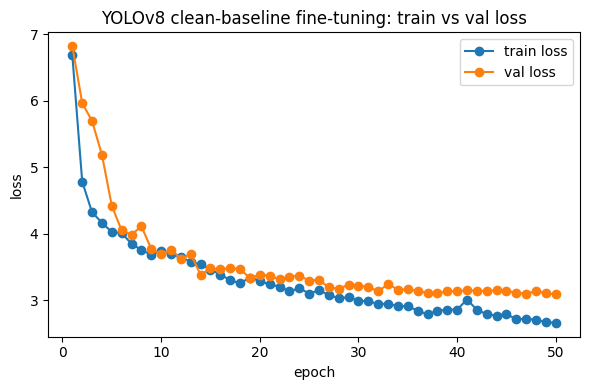

In [10]:
checkpoint_path = object_detection.checkpoint_path_for("clean_baseline")
if not checkpoint_path.exists():
    data_yaml = kitti_yolo_format.build_yolo_dataset(detection_splits)
    checkpoint_path = object_detection.fine_tune(data_yaml, run_name="clean_baseline")
(config.CHECKPOINT_ROOT / "yolo_clean_baseline_path.txt").write_text(str(checkpoint_path))

yolo_model = YOLO(checkpoint_path)

training_curve = object_detection.load_training_curve(checkpoint_path)
fig = plot_metric_vs_intensity(
    training_curve["epoch"],
    {"train loss": training_curve["train_loss"], "val loss": training_curve["val_loss"]},
    xlabel="epoch", ylabel="loss", title="YOLOv8 clean-baseline fine-tuning: train vs val loss",
)
save_figure(fig, "02_clean_baseline/yolo_training_curve.png")

**train loss:** Measured on the images the model is actively adjusting its weights on.


**val loss:** Measured at the end of each epoch on the held-out validation images. Because the model doesn't update its weights using these images, val loss serves as an honest check to see if the model actually learned general patterns or simply memorized the training set (overfitting).


**Both train loss and val loss drop steeply from ~6.7 down to ~3.7 within the first 10 epochs.**


This confirms that the learning rate is well-tuned and the model is rapidly adapting its weights to the KITTI target domain.


No Overfitting:


val loss tracks train loss closely throughout all 50 epochs.


Crucially, the validation loss does not bend upward at later epochs. A rising validation loss while training loss continues to fall would indicate overfitting; here, validation loss flattens and stays steady around ~3.1, showing strong generalization.


Convergence & Plateau (~Epoch 30–50):


After Epoch 30, the validation loss plateaus around 3.1, while training loss gently creeps down to ~2.7.


The slight gap between train loss (2.7) and val loss (3.1) is expected due to standard training augmentations and small dataset sampling variance.



## Step 2: verify SegFormer/KITTI class alignment, then load

In [11]:
segformer_model, segformer_processor = semantic_segmentation.load_pretrained()
aligned = semantic_segmentation.verify_class_alignment(segformer_model)
print("SegFormer/KITTI Semantics class alignment:", aligned)
assert aligned, (
    "Checkpoint class order does not match KITTI Semantics - populate "
    "config.SEGFORMER_CLASS_ID_REMAP before trusting segmentation metrics."
)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegFormer/KITTI Semantics class alignment: True


## Step 3: run all 4 tasks on clean images

In [12]:
# Feature matching: no GT correspondence dataset to compare to on clean-only
# images, so keypoint yield is one clean baseline. Match accuracy also gets a
# clean baseline here via clean-vs-clean self-matching (a trivial/ceiling
# case) - the meaningful clean-vs-distorted match accuracy comparisons start
# in 03.
orb_keypoint_counts = []
match_accuracies_clean = []
for sample in detection_splits["test"][:20]:
    image = read_image(sample.image_path)
    keypoints, _ = feature_matching.detect_and_describe(image)
    orb_keypoint_counts.append(len(keypoints))
    _, _, _, accuracy, _ = feature_matching.match(image, image)
    match_accuracies_clean.append(accuracy)

mean_orb_keypoints = float(np.mean(orb_keypoint_counts))
mean_orb_match_accuracy_clean = float(np.mean(match_accuracies_clean))
print(f"Mean ORB keypoints on clean test images: {mean_orb_keypoints:.1f}")
print(f"Mean ORB clean-vs-clean self-match accuracy: {mean_orb_match_accuracy_clean:.3f}")

Mean ORB keypoints on clean test images: 1000.0
Mean ORB clean-vs-clean self-match accuracy: 1.000


In [13]:
epe_values = []
fl_error_values = []
for sample in flow_splits["test"]:
    frame1 = read_image(sample.frame1_path)
    frame2 = read_image(sample.frame2_path)
    gt_flow, valid = read_kitti_flow_png(sample.flow_gt_path)
    flow_metrics = optical_flow.evaluate(frame1, frame2, gt_flow, valid)
    epe_values.append(flow_metrics["epe"])
    fl_error_values.append(flow_metrics["fl_error"])

baseline_epe = float(np.mean(epe_values))
baseline_fl_error = float(np.mean(fl_error_values))
print(f"Baseline (clean) optical flow EPE: {baseline_epe:.3f}, Fl-error: {baseline_fl_error:.3f}")

Baseline (clean) optical flow EPE: 28.648, Fl-error: 0.558


**End-Point Error** is the average Euclidean distance (in pixels) between the predicted 2D optical flow vector $(u_{\text{pred}}, v_{\text{pred}})$ and the ground-truth motion vector $(u_{\text{gt}}, v_{\text{gt}})$ across all valid pixels.


 On clean test image pairs, the predicted pixel motion vectors miss the true motion by an average of 28.648 pixels.


**Flow Error Rate (Outlier Ratio):** A value of 0.558 means that 55.8\% of all evaluated pixels were classified as flow estimation outliers on the clean test set.


Baseline (clean) detection mAP@0.5:0.95: 0.260, mAP@0.5: 0.417, mAP@0.75: 0.282, mAR@100: 0.301
Undefined AP (no ground truth in this test split), excluded from chart: ['Person_sitting']


PosixPath('/content/Image-Processing-Project/figures/02_clean_baseline/detection_map_per_class.png')

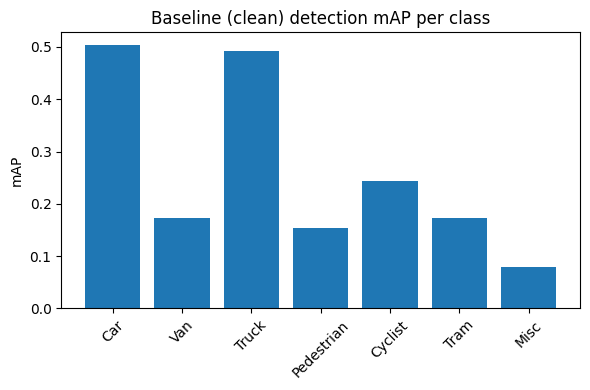

In [14]:
baseline_detection_metrics = object_detection.evaluate(yolo_model, detection_splits["test"])
baseline_map = float(baseline_detection_metrics["map"])
baseline_map_50 = float(baseline_detection_metrics["map_50"])
baseline_map_75 = float(baseline_detection_metrics["map_75"])
baseline_mar_100 = float(baseline_detection_metrics["mar_100"])
print(
    f"Baseline (clean) detection mAP@0.5:0.95: {baseline_map:.3f}, "
    f"mAP@0.5: {baseline_map_50:.3f}, mAP@0.75: {baseline_map_75:.3f}, mAR@100: {baseline_mar_100:.3f}"
)

# per_class_ap_dict() already drops classes whose AP is torchmetrics/pycocotools'
# -1 "undefined" sentinel (no valid ground truth for that class in this test
# split) - report which classes that was so the gap is visible rather than
# silently missing from the chart below.
baseline_detection_by_class = per_class_ap_dict(baseline_detection_metrics)
undefined_classes = [c for c in config.KITTI_DETECTION_CLASSES if c not in baseline_detection_by_class]
if undefined_classes:
    print(f"Undefined AP (no ground truth in this test split), excluded from chart: {undefined_classes}")

fig = plot_bar_per_class(
    list(baseline_detection_by_class.keys()), list(baseline_detection_by_class.values()),
    ylabel="mAP", title="Baseline (clean) detection mAP per class",
)
save_figure(fig, "02_clean_baseline/detection_map_per_class.png")

Highest Performing Classes: Car (0.50) and Truck (0.49) have the highest mAP.
Person_sitting is the rarest class in the dataset and no ground-truth instances of that class were present in the evaluation test.


Baseline (clean) segmentation mean IoU: 0.387


PosixPath('/content/Image-Processing-Project/figures/02_clean_baseline/segmentation_iou_per_class.png')

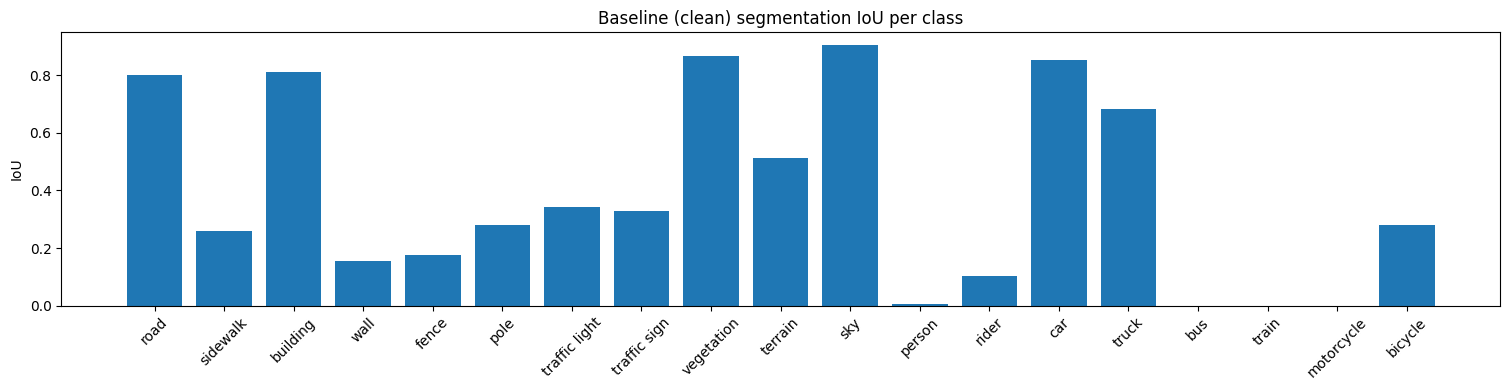

In [15]:
baseline_segmentation_iou = semantic_segmentation.evaluate(segformer_model, segformer_processor, segmentation_splits["test"])
baseline_mean_iou = float(baseline_segmentation_iou.mean())
print(f"Baseline (clean) segmentation mean IoU: {baseline_mean_iou:.3f}")

fig = plot_bar_per_class(
    config.CITYSCAPES_TRAINID_LABELS, baseline_segmentation_iou.tolist(),
    ylabel="IoU", title="Baseline (clean) segmentation IoU per class",
)
save_figure(fig, "02_clean_baseline/segmentation_iou_per_class.png")

**Mean Intersection over Union (mIoU):**

Top Performing Classes: Sky (0.90), Vegetation (0.87), Car (0.85), Building (0.81), and Road (0.80).

Low / Zero Performing Classes: Person (~0.01), Rider (0.10), Bus (0.0), Train (0.0), Motorcycle (0.0). The reason might be class imbalance or total absence of certain categories in the specific test slice evaluated.

## Baseline summary table

In [16]:
config.RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

baseline_summary = pd.DataFrame([
    {"task": "feature_matching", "metric": "mean_orb_keypoints_clean", "value": mean_orb_keypoints},
    {"task": "feature_matching", "metric": "match_accuracy", "value": mean_orb_match_accuracy_clean},
    {"task": "optical_flow", "metric": "epe", "value": baseline_epe},
    {"task": "optical_flow", "metric": "fl_error", "value": baseline_fl_error},
    {"task": "object_detection", "metric": "map", "value": baseline_map},
    {"task": "object_detection", "metric": "map_50", "value": baseline_map_50},
    {"task": "object_detection", "metric": "map_75", "value": baseline_map_75},
    {"task": "object_detection", "metric": "mar_100", "value": baseline_mar_100},
    {"task": "semantic_segmentation", "metric": "mean_iou", "value": baseline_mean_iou},
])
baseline_summary.to_csv(config.RESULTS_ROOT / "02_clean_baseline.csv", index=False)
save_results_csv(baseline_summary, "02_clean_baseline/summary.csv")
baseline_summary

,task,metric,value
0,feature_matching,mean_orb_keypoints_clean,1000.000000
1,feature_matching,match_accuracy,1.000000
2,optical_flow,epe,28.648050
3,optical_flow,fl_error,0.558026
4,object_detection,map,0.260119
5,object_detection,map_50,0.417080
6,object_detection,map_75,0.282112
7,object_detection,mar_100,0.301389
8,semantic_segmentation,mean_iou,0.387416


## Sync figures/results back to GitHub

`figures/` and `results/` only exist inside this run's throwaway Colab clone
(see the setup cell) - back them up to Drive and push straight to GitHub so
the README's plots/tables actually update. Requires a one-time `GITHUB_TOKEN`
secret in Colab (see this repo's README, "Running on Colab").

In [17]:
from ipproj.colab_sync import sync_outputs_to_drive, git_commit_and_push

if IN_COLAB:
    sync_outputs_to_drive()
    git_commit_and_push("Sync figures/results from notebook 02 (clean baseline) run")